# MolGNN Data and Setup


In [ ]:
%pip install -r requirements.txt

In [1]:
import os
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from torch_geometric.datasets import MoleculeNet
from rdkit import Chem
from rdkit.Chem import Draw

from scripts.models import (
    GraphConvolutionalNetwork,
    GraphAttentionNetwork,
    GraphIsomorphismNetwork,
    GraphAttentionV2Network,
    GraphTransformerNetwork,
    load_model,
)
from scripts.train import train_model
from scripts.eval import evaluate_model
from scripts.inference import smiles_to_data, predict_log_solubility_from_smiles

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

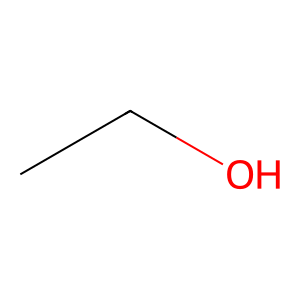

In [2]:
# SMILES renderer example

# Ethanol
smiles_example = "CCO"

# Convert SMILES to molecule
molecule_example = Chem.MolFromSmiles(smiles_example)

# Visualize molecule
Draw.MolToImage(molecule_example)

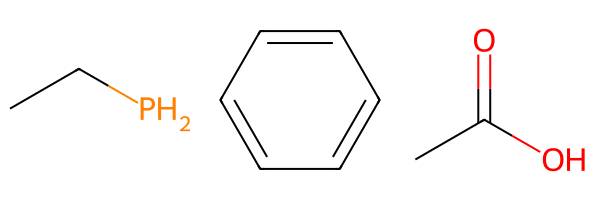

In [3]:
# Ethanol, Benzene, Acetic Acid
smiles_examples_list = ["CCP", "C1=CC=CC=C1", "CC(=O)O"]

molecules_example = [Chem.MolFromSmiles(example) for example in smiles_examples_list]

Draw.MolsToGridImage(molecules_example, molsPerRow=3, subImgSize=(200, 200))

In [4]:
def load_molecule_data(
    dataset_name: str = "ESOL", data_dir: str = "data/MoleculeNet"
) -> tuple[Data]:
    dataset = MoleculeNet(root=data_dir, name=dataset_name)
    return dataset

In [5]:
dataset = load_molecule_data(dataset_name="ESOL", data_dir="data/MoleculeNet")

len(dataset)

1128

In [6]:
test_idx = 0
print(
    f"Dataset tensor and SMILES tensor match: {torch._is_all_true(dataset[test_idx].x == smiles_to_data(smiles=dataset[test_idx].smiles).x)}"
)

Dataset tensor and SMILES tensor match: True


In [8]:
dataset[test_idx]

Data(x=[32, 9], edge_index=[2, 68], edge_attr=[68, 3], smiles='OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O ', y=[1, 1])

In [ ]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
len(train_dataset), len(test_dataset)

In [ ]:
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=os.cpu_count(),
    pin_memory=True,
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=os.cpu_count(),
    pin_memory=True,
)

len(train_dataloader), len(test_dataloader)

In [ ]:
test_batch = next(iter(train_dataloader))
test_batch

# Graph Convolutional Network (GCN)


In [ ]:
gcn_model = GraphConvolutionalNetwork(
    num_layers=3,
    in_channels=dataset.num_features,
    hidden_channels=128,
    out_channels=1,
    dropout=0.1,
).to(device)

gcn_optimizer = torch.optim.AdamW(
    params=gcn_model.parameters(), lr=1e-3, weight_decay=1e-4
)
loss_fn = nn.MSELoss()

print(
    f"The GCN model has: {sum(param.numel() for param in gcn_model.parameters()):,} total parameters"
)

In [ ]:
num_epochs = 400

gcn_model, gcn_train_losses, gcn_test_losses, gcn_test_maes = train_model(
    model=gcn_model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=gcn_optimizer,
    loss_fn=loss_fn,
    num_epochs=num_epochs,
    save_path="models/gcn_model.pt",
    device=device,
)

In [ ]:
gcn_test_loss, gcn_test_mae = evaluate_model(
    model=gcn_model,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    device=device,
)

In [ ]:
idx = 0
test_smiles_seq = test_dataset[idx].smiles
true_log_sol = test_dataset[idx].y.item()

gcn_predicted_log_sol = predict_log_solubility_from_smiles(
    model=gcn_model, smiles_seq=test_smiles_seq, device=device
)
print(f"Ground-truth Log Solubility: {true_log_sol:.4f} mol/L")
print(f"Absolute Error: {abs(gcn_predicted_log_sol - true_log_sol):.4f} mol/L")

# Graph Attention Network (GAT)


In [ ]:
gat_model = GraphAttentionNetwork(
    num_layers=3,
    in_channels=dataset.num_features,
    hidden_channels=128,
    out_channels=1,
    heads=4,
    dropout=0.1,
).to(device)

gat_optimizer = torch.optim.AdamW(
    params=gat_model.parameters(), lr=1e-3, weight_decay=1e-4
)
loss_fn = nn.MSELoss()

print(
    f"The GAT model has: {sum(param.numel() for param in gat_model.parameters()):,} total parameters"
)

In [ ]:
num_epochs = 400

gat_model, gat_train_losses, gat_test_losses, gat_test_maes = train_model(
    model=gat_model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=gat_optimizer,
    loss_fn=loss_fn,
    num_epochs=num_epochs,
    save_path="models/gat_model.pt",
    device=device,
)

In [ ]:
gat_test_loss, gat_test_mae = evaluate_model(
    model=gat_model,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    device=device,
)

In [ ]:
idx = 0
test_smiles_seq = test_dataset[idx].smiles
true_log_sol = test_dataset[idx].y.item()

gat_predicted_log_sol = predict_log_solubility_from_smiles(
    model=gat_model, smiles_seq=test_smiles_seq, device=device
)
print(f"Ground-truth Log Solubility: {true_log_sol:.4f} mol/L")
print(f"Absolute Error: {abs(gat_predicted_log_sol - true_log_sol):.4f} mol/L")

# Graph Isomorphism Network (GIN)


In [ ]:
gin_model = GraphIsomorphismNetwork(
    num_layers=4,
    in_channels=dataset.num_features,
    hidden_channels=128,
    out_channels=1,
    dropout=0.1,
).to(device)

gin_optimizer = torch.optim.AdamW(
    params=gin_model.parameters(), lr=1e-3, weight_decay=1e-4
)
loss_fn = nn.MSELoss()

print(
    f"The GIN model has: {sum(param.numel() for param in gin_model.parameters()):,} total parameters"
)

In [ ]:
num_epochs = 500

gin_model, gin_train_losses, gin_test_losses, gin_test_maes = train_model(
    model=gin_model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=gin_optimizer,
    loss_fn=loss_fn,
    num_epochs=num_epochs,
    save_path="models/gin_model.pt",
    device=device,
)

In [ ]:
gin_test_loss, gin_test_mae = evaluate_model(
    model=gin_model,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    device=device,
)

In [ ]:
idx = 0
test_smiles_seq = test_dataset[idx].smiles
true_log_sol = test_dataset[idx].y.item()

gin_predicted_log_sol = predict_log_solubility_from_smiles(
    model=gin_model, smiles_seq=test_smiles_seq, device=device
)
print(f"Ground-truth Log Solubility: {true_log_sol:.4f} mol/L")
print(f"Absolute Error: {abs(gin_predicted_log_sol - true_log_sol):.4f} mol/L")

# Graph Attention Network V2 (GATV2)


In [ ]:
gat_v2_model = GraphAttentionV2Network(
    num_layers=3,
    in_channels=dataset.num_features,
    hidden_channels=128,
    out_channels=1,
    heads=4,
    edge_dim=dataset[0].edge_attr.shape[1],
    dropout=0.15,
).to(device)

gat_v2_optimizer = torch.optim.AdamW(
    params=gat_v2_model.parameters(), lr=5e-4, weight_decay=1e-4
)
loss_fn = nn.MSELoss()

print(
    f"The GATv2 model has: {sum(param.numel() for param in gat_v2_model.parameters()):,} total parameters"
)

In [ ]:
num_epochs = 400

gat_v2_model, gat_v2_train_losses, gat_v2_test_losses, gat_v2_test_maes = train_model(
    model=gat_v2_model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=gat_v2_optimizer,
    loss_fn=loss_fn,
    num_epochs=num_epochs,
    save_path="models/gat_v2_model.pt",
    device=device,
)

In [ ]:
gat_v2_test_loss, gat_v2_test_mae = evaluate_model(
    model=gat_v2_model,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    device=device,
)

In [ ]:
idx = 0
test_smiles_seq = test_dataset[idx].smiles
true_log_sol = test_dataset[idx].y.item()

gat_v2_predicted_log_sol = predict_log_solubility_from_smiles(
    model=gat_v2_model, smiles_seq=test_smiles_seq, device=device
)
print(f"Ground-truth Log Solubility: {true_log_sol:.4f} mol/L")
print(f"Absolute Error: {abs(gat_v2_predicted_log_sol - true_log_sol):.4f} mol/L")

# Graph Transformer


In [ ]:
graph_transformer_model = GraphTransformerNetwork(
    num_layers=3,
    in_channels=dataset.num_features,
    hidden_channels=128,
    out_channels=1,
    heads=4,
    edge_dim=dataset[0].edge_attr.shape[1],
    dropout=0.15,
).to(device)

graph_transformer_optimizer = torch.optim.AdamW(
    params=graph_transformer_model.parameters(), lr=5e-4, weight_decay=1e-4
)
loss_fn = nn.MSELoss()

print(
    f"The Graph Transformer model has: {sum(param.numel() for param in graph_transformer_model.parameters()):,} total parameters"
)

In [ ]:
num_epochs = 400

(
    graph_transformer_model,
    graph_transformer_train_losses,
    graph_transformer_test_losses,
    graph_transformer_test_maes,
) = train_model(
    model=graph_transformer_model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=graph_transformer_optimizer,
    loss_fn=loss_fn,
    num_epochs=num_epochs,
    save_path="models/graph_transformer_model.pt",
    device=device,
)

In [ ]:
graph_transformer_test_loss, graph_transformer_test_mae = evaluate_model(
    model=graph_transformer_model,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    device=device,
)

In [ ]:
idx = 0
test_smiles_seq = test_dataset[idx].smiles
true_log_sol = test_dataset[idx].y.item()

graph_transformer_predicted_log_sol = predict_log_solubility_from_smiles(
    model=graph_transformer_model, smiles_seq=test_smiles_seq, device=device
)
print(f"Ground-truth Log Solubility: {true_log_sol:.4f} mol/L")
print(
    f"Absolute Error: {abs(graph_transformer_predicted_log_sol - true_log_sol):.4f} mol/L"
)